# Segmentacion de Clientes: FISIMart S.A.C.

Segmentacion de clientes mediante analisis **RFM (Recencia, Frecuencia, Monto)** y **clustering K-Means**, con el objetivo de identificar grupos de comportamiento de compra, perfilarlos con datos demograficos y del programa de fidelizacion, y proponer estrategias comerciales diferenciadas por segmento.

#### CELDA 1: CONTROL DE ENTORNO E IMPORTACION

In [1]:
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Configuracion visual (igual a 02_visualizacion.ipynb)
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12

# Paleta corporativa oficial de FISIMart
PALETA_FISIMART = ["#1f77b4", "#aec7e8", "#ff7f0e", "#ffbb78", "#4d4d4d"]
sns.set_palette(sns.color_palette(PALETA_FISIMART))

# Rutas relativas desde notebooks/
RUTA_PROCESSED = "../data/processed"
ARCHIVO_FACT_VENTAS = f"{RUTA_PROCESSED}/Fact_Ventas.csv"
ARCHIVO_DIM_CLIENTE = f"{RUTA_PROCESSED}/Dim_Cliente.csv"
ARCHIVO_SEGMENTACION_EXPORT = f"{RUTA_PROCESSED}/Segmentacion_Clientes.csv"

os.makedirs('../reports/figures', exist_ok=True)

SEMILLA = 20
np.random.seed(SEMILLA)

print("=" * 72)
print("     SEGMENTACION DE CLIENTES — FISIMart S.A.C. (RFM + K-Means)")
print("=" * 72)
print(f"● Datamart procesado : {RUTA_PROCESSED}/")
print(f"● Semilla aleatoria  : {SEMILLA}")
print("=" * 72)


     SEGMENTACION DE CLIENTES — FISIMart S.A.C. (RFM + K-Means)
● Datamart procesado : ../data/processed/
● Semilla aleatoria  : 20


#### CELDA 2: CARGA DE DATOS PROCESADOS

In [2]:
Fact_Ventas = pd.read_csv(ARCHIVO_FACT_VENTAS, sep=";", encoding="utf-8")
Dim_Cliente = pd.read_csv(ARCHIVO_DIM_CLIENTE, sep=";", encoding="utf-8")

Fact_Ventas["fecha"] = pd.to_datetime(Fact_Ventas["fecha"])

n_clientes_dim = Dim_Cliente["id_cliente"].nunique()
n_clientes_con_compras = Fact_Ventas["id_cliente"].nunique()
n_clientes_sin_compras = n_clientes_dim - n_clientes_con_compras

print("Resumen inicial del universo de clientes:")
print(f"  • Clientes en Dim_Cliente              : {n_clientes_dim:,}")
print(f"  • Clientes con al menos una compra      : {n_clientes_con_compras:,}")
print(f"  • Clientes sin compras registradas      : {n_clientes_sin_compras:,}")
print(f"  • Rango de fechas de venta              : {Fact_Ventas['fecha'].min().date()} a {Fact_Ventas['fecha'].max().date()}")
print(f"  • Boletas unicas (id_venta)             : {Fact_Ventas['id_venta'].nunique():,}")


Resumen inicial del universo de clientes:
  • Clientes en Dim_Cliente              : 5,000
  • Clientes con al menos una compra      : 3,641
  • Clientes sin compras registradas      : 1,359
  • Rango de fechas de venta              : 2024-01-01 a 2025-12-31
  • Boletas unicas (id_venta)             : 12,750


#### CELDA 3: CALCULO RFM (una fila por cliente)

Los **1,359 clientes sin compras registradas** en `Fact_Ventas` no tienen historial
transaccional, por lo que no es posible calcular Recencia/Frecuencia/Monto reales para ellos.
Se excluyen del analisis RFM y del clustering (no se les asigna un valor artificial); el
analisis se construye sobre los **3,641 clientes con al menos una compra**.

**Fecha de corte:** se usa `max(fecha) + 1 dia` del propio dataset transaccional (no la fecha
actual del sistema), ya que el dataset simulado termina el 2025-12-31. Esto da una fecha de
corte de 2026-01-01, y evita que la Recencia dependa de cuando se ejecute el notebook.

- **Recency** = dias entre la fecha de corte y la ultima compra del cliente.
- **Frequency** = numero de boletas distintas (`id_venta` unicos) del cliente.
- **Monetary** = suma del `importe` de todas las lineas de venta del cliente.

In [3]:
fecha_corte = Fact_Ventas["fecha"].max() + pd.Timedelta(days=1)

rfm = (
    Fact_Ventas
    .groupby("id_cliente")
    .agg(
        Recency=("fecha", lambda x: (fecha_corte - x.max()).days),
        Frequency=("id_venta", "nunique"),
        Monetary=("importe", "sum"),
    )
    .reset_index()
)

print(f"Fecha de corte utilizada : {fecha_corte.date()}")
print(f"Clientes con RFM calculado : {len(rfm):,}")
print("\nEstadisticas descriptivas de RFM:")
display(rfm[["Recency", "Frequency", "Monetary"]].describe().round(2))
print("\nVista previa:")
display(rfm.head())


Fecha de corte utilizada : 2026-01-01
Clientes con RFM calculado : 3,641

Estadisticas descriptivas de RFM:


,Recency,Frequency,Monetary
count,3641.00,3641.00,3641.00
mean,213.69,3.50,841.35
std,190.54,2.94,769.16
min,1.00,1.00,4.14
25%,37.00,1.00,293.93
50%,170.00,3.00,615.28
75%,366.00,5.00,1142.35
max,731.00,31.00,7175.35



Vista previa:


,id_cliente,Recency,Frequency,Monetary
0,CLI00002,354,5,744.70
1,CLI00003,467,1,28.80
2,CLI00004,11,14,2930.78
3,CLI00007,16,4,926.50
4,CLI00009,165,5,761.02


#### CELDA 4: SCORES RFM POR QUINTILES (1-5)

Se divide cada metrica en 5 quintiles (`pd.qcut`). Para **Recency** el orden se invierte:
el quintil con menos dias desde la ultima compra (mas reciente) recibe el score mas alto (5),
mientras que en **Frequency** y **Monetary** el quintil mas alto recibe directamente el score
mas alto (5), ya que comprar mas seguido y gastar mas es mejor.

In [4]:
def score_por_quintil(serie, labels_ascendente):
    """Asigna score 1-5 por quintil. Rompe empates con rank() antes de qcut
    porque Frequency y Monetary tienen muchos valores repetidos."""
    rangos = serie.rank(method="first")
    return pd.qcut(rangos, q=5, labels=labels_ascendente).astype(int)

rfm["R_Score"] = score_por_quintil(rfm["Recency"], [5, 4, 3, 2, 1])
rfm["F_Score"] = score_por_quintil(rfm["Frequency"], [1, 2, 3, 4, 5])
rfm["M_Score"] = score_por_quintil(rfm["Monetary"], [1, 2, 3, 4, 5])

rfm["RFM_Score"] = (
    rfm["R_Score"].astype(str) + rfm["F_Score"].astype(str) + rfm["M_Score"].astype(str)
)

print("Distribucion de scores individuales:")
for col in ["R_Score", "F_Score", "M_Score"]:
    print(f"\n{col}:")
    print(rfm[col].value_counts().sort_index())

print("\nVista previa RFM con scores:")
display(rfm.head(10))


Distribucion de scores individuales:

R_Score:
R_Score
1    728
2    728
3    728
4    728
5    729
Name: count, dtype: int64

F_Score:
F_Score
1    729
2    728
3    728
4    728
5    728
Name: count, dtype: int64

M_Score:
M_Score
1    729
2    728
3    728
4    728
5    728
Name: count, dtype: int64

Vista previa RFM con scores:


,id_cliente,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score
0,CLI00002,354,5,744.70,2,4,3,243
1,CLI00003,467,1,28.80,1,1,1,111
2,CLI00004,11,14,2930.78,5,5,5,555
3,CLI00007,16,4,926.50,5,4,4,544
4,CLI00009,165,5,761.02,3,4,3,343
5,CLI00010,412,1,42.64,1,1,1,111
6,CLI00012,243,2,244.93,2,2,2,222
7,CLI00013,10,8,1355.29,5,5,5,555
8,CLI00014,9,2,717.54,5,2,3,523
9,CLI00015,196,1,320.62,3,1,2,312


#### CELDA 5: JUSTIFICACION DEL METODO DE CLUSTERING

Los scores 1-5 son utiles para lectura rapida, pero al ser discretos (solo 5 niveles por
variable) pierden granularidad: dos clientes en el mismo quintil de Monetary pueden tener
montos muy distintos dentro del rango. Por eso el clustering se aplica sobre los valores
**continuos** de Recency, Frequency y Monetary (no sobre los scores), estandarizados con
`StandardScaler` para que ninguna variable domine por su escala (Monetary esta en soles y
Recency en dias, con rangos muy distintos). Se usa **K-Means** por ser el algoritmo estandar
para segmentacion RFM: simple de interpretar, escala bien a miles de clientes y produce
centroides que se leen directamente como "cliente promedio del segmento".

#### CELDA 6: ESTANDARIZACION + METODO DEL CODO + SILHOUETTE

Metricas por numero de clusters (k):


,k,inercia,silhouette
0,2,5718.308744,0.464073
1,3,3354.782482,0.443884
2,4,2372.118130,0.428746
3,5,1973.228737,0.397909
4,6,1647.027786,0.362026
5,7,1452.443103,0.336778
6,8,1278.905216,0.358630
7,9,1126.646817,0.352581
8,10,1020.449572,0.347172


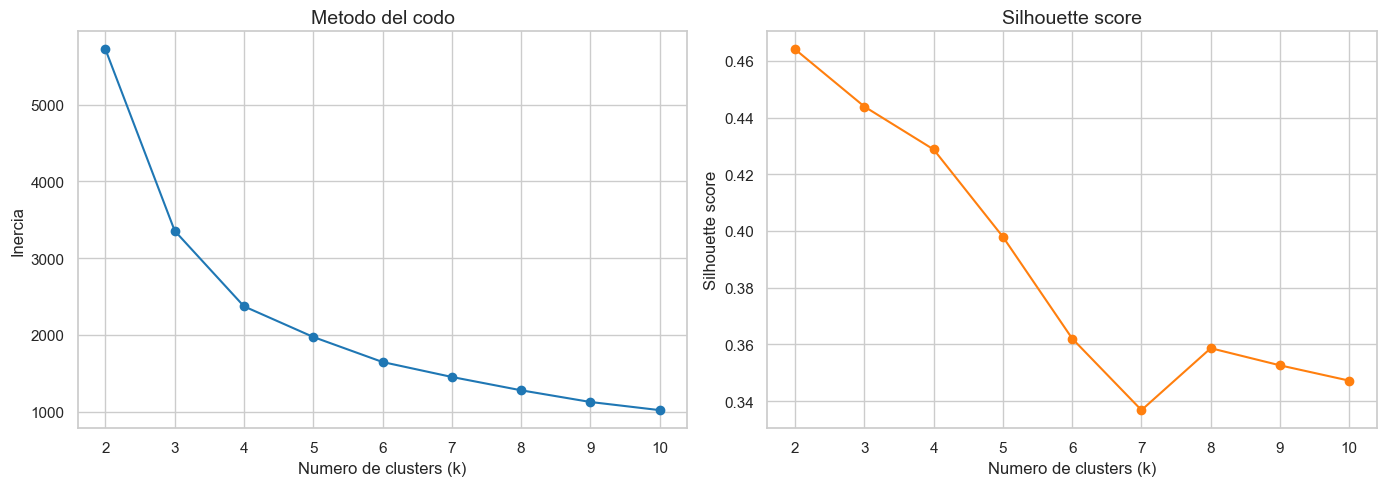

In [5]:
columnas_rfm = ["Recency", "Frequency", "Monetary"]
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm[columnas_rfm])

rango_k = range(2, 11)
inercias = []
silhouettes = []

for k in rango_k:
    km = KMeans(n_clusters=k, random_state=SEMILLA, n_init=10)
    labels_k = km.fit_predict(rfm_scaled)
    inercias.append(km.inertia_)
    silhouettes.append(silhouette_score(rfm_scaled, labels_k))

resultados_k = pd.DataFrame({
    "k": list(rango_k),
    "inercia": inercias,
    "silhouette": silhouettes,
})
print("Metricas por numero de clusters (k):")
display(resultados_k)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(resultados_k["k"], resultados_k["inercia"], marker="o", color=PALETA_FISIMART[0])
axes[0].set_title("Metodo del codo")
axes[0].set_xlabel("Numero de clusters (k)")
axes[0].set_ylabel("Inercia")
axes[0].set_xticks(list(rango_k))

axes[1].plot(resultados_k["k"], resultados_k["silhouette"], marker="o", color=PALETA_FISIMART[2])
axes[1].set_title("Silhouette score")
axes[1].set_xlabel("Numero de clusters (k)")
axes[1].set_ylabel("Silhouette score")
axes[1].set_xticks(list(rango_k))

plt.tight_layout()
plt.savefig('../reports/figures/05_codo_silhouette.png', dpi=300)
plt.show()


#### CELDA 7: ELECCION DE K

**Resultados obtenidos:**

| k | inercia | silhouette |
|---|---------|------------|
| 2 | 5718.31 | 0.4641 |
| 3 | 3354.78 | 0.4439 |
| 4 | 2372.12 | 0.4287 |
| 5 | 1973.23 | 0.3979 |
| 6 | 1647.03 | 0.3620 |
| 7 | 1452.44 | 0.3368 |
| 8 | 1278.91 | 0.3586 |
| 9 | 1126.65 | 0.3526 |
| 10 | 1020.45 | 0.3472 |

**Se elige k = 4.** La inercia cae fuertemente hasta k=3 (-2364 de k=2 a k=3, -982 de k=3 a k=4)
y luego se aplana: de k=4 en adelante la reduccion marginal por cada cluster adicional es cada
vez mas pequena (-399, -326, -195...), es decir, el "codo" de la curva esta entre k=3 y k=4.
El silhouette score decrece de forma monotona con k (esperable: k=2 siempre separa mejor de
forma trivial), pero en k=4 todavia se mantiene alto (0.43, muy cerca del 0.44 de k=3 y muy por
encima del rango 0.33-0.36 que se observa desde k=6 en adelante). k=4 es ademas el numero minimo
de segmentos que permite distinguir los 4 arquetipos de negocio esperados en RFM (Campeones,
Leales, En Riesgo, Perdidos), por lo que se prioriza frente a k=3 (que fusionaria dos de esos
perfiles) sin sacrificar calidad de separacion frente a k=5 o mas.

#### CELDA 8: MODELO FINAL Y ASIGNACION DE CLUSTER

In [6]:
K_ELEGIDO = 4

kmeans_final = KMeans(n_clusters=K_ELEGIDO, random_state=SEMILLA, n_init=10)
rfm["Cluster"] = kmeans_final.fit_predict(rfm_scaled)

print(f"Modelo K-Means final ajustado con k = {K_ELEGIDO}, random_state = {SEMILLA}")
print("\nClientes por cluster:")
display(rfm["Cluster"].value_counts().sort_index())

print("\nCentroides (escala estandarizada):")
centroides = pd.DataFrame(kmeans_final.cluster_centers_, columns=columnas_rfm)
display(centroides.round(3))


Modelo K-Means final ajustado con k = 4, random_state = 20

Clientes por cluster:


Cluster
0     870
1     254
2    1071
3    1446
Name: count, dtype: int64


Centroides (escala estandarizada):


,Recency,Frequency,Monetary
0,-0.630,0.760,0.726
1,-0.825,2.583,2.619
2,1.338,-0.643,-0.623
3,-0.467,-0.435,-0.435


#### CELDA 9: VISUALIZACION DE CLUSTERS EN EL ESPACIO RFM

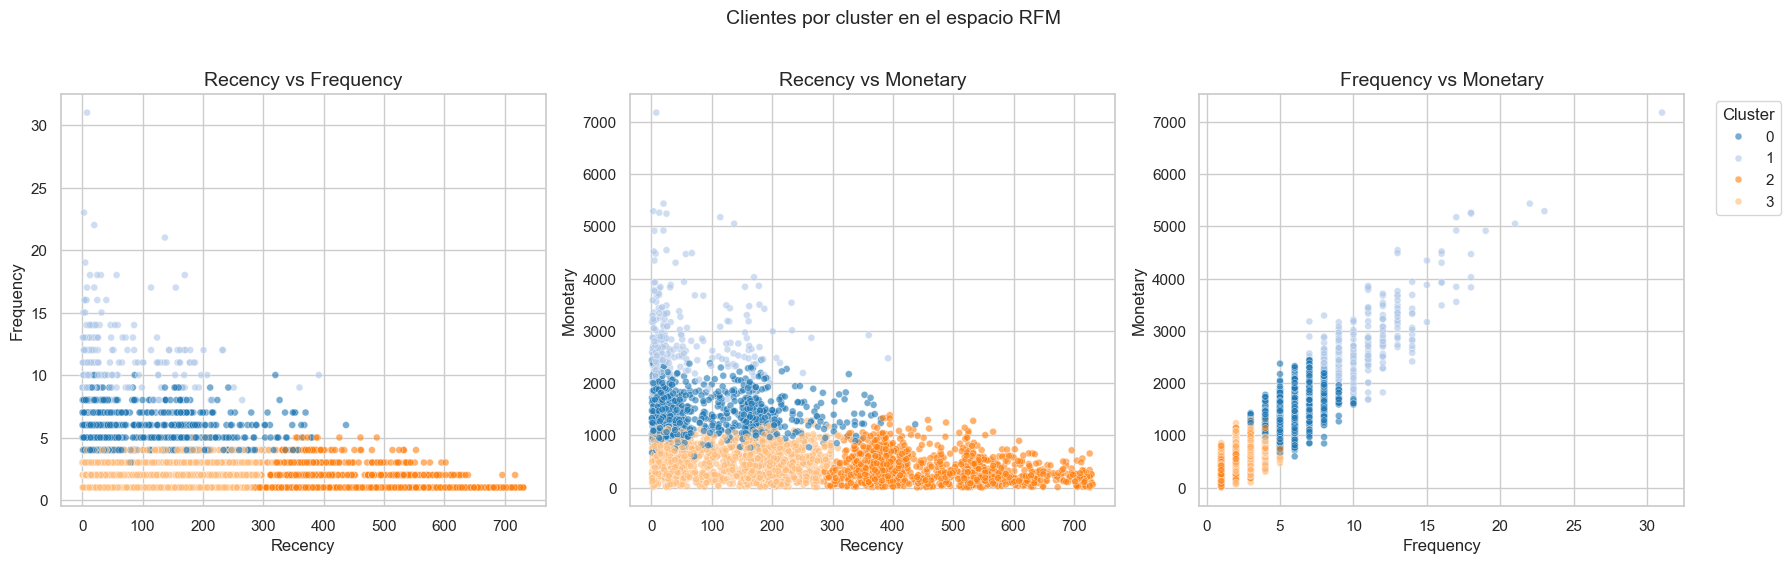

In [7]:
pares = [("Recency", "Frequency"), ("Recency", "Monetary"), ("Frequency", "Monetary")]
fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))

for ax, (x, y) in zip(axes, pares):
    sns.scatterplot(
        data=rfm, x=x, y=y, hue="Cluster",
        palette=PALETA_FISIMART[:K_ELEGIDO],
        alpha=0.6, s=25, ax=ax, legend=(ax is axes[-1]),
    )
    ax.set_title(f"{x} vs {y}")

axes[-1].legend(title="Cluster", bbox_to_anchor=(1.05, 1), loc="upper left")

plt.suptitle("Clientes por cluster en el espacio RFM", y=1.02, fontsize=14)
plt.tight_layout()
plt.savefig('../reports/figures/06_clusters_rfm.png', dpi=300, bbox_inches="tight")
plt.show()


#### CELDA 10: PERFILES DE CLUSTER (cruce con Dim_Cliente)

In [8]:
rfm_perfil = rfm.merge(
    Dim_Cliente[["id_cliente", "edad", "ingresos_mensuales_aprox", "segmento_programa", "distrito"]],
    on="id_cliente",
    how="left",
)

def moda(serie):
    return serie.mode().iloc[0]

perfiles = (
    rfm_perfil
    .groupby("Cluster")
    .agg(
        n_clientes=("id_cliente", "count"),
        Recency_media=("Recency", "mean"),
        Frequency_media=("Frequency", "mean"),
        Monetary_media=("Monetary", "mean"),
        edad_media=("edad", "mean"),
        ingresos_medios=("ingresos_mensuales_aprox", "mean"),
        segmento_programa_moda=("segmento_programa", moda),
        distrito_moda=("distrito", moda),
    )
    .round(1)
)
perfiles["pct_clientes"] = (perfiles["n_clientes"] / perfiles["n_clientes"].sum() * 100).round(1)

print("Perfiles por cluster:")
display(perfiles)

print("\nComposicion de segmento_programa por cluster (%):")
display(
    pd.crosstab(rfm_perfil["Cluster"], rfm_perfil["segmento_programa"], normalize="index")
    .mul(100).round(1)
)


Perfiles por cluster:


,n_clientes,Recency_media,Frequency_media,Monetary_media,edad_media,ingresos_medios,segmento_programa_moda,distrito_moda,pct_clientes
Cluster,,,,,,,,,
0,870,93.7,5.7,1399.4,45.9,6390.4,Platino,San Juan de Lurigancho,23.9
1,254,56.6,11.1,2855.3,44.7,6666.5,Platino,Ate,7.0
2,1071,468.5,1.6,362.4,46.4,5586.4,Basico,Santiago de Surco,29.4
3,1446,124.8,2.2,506.5,46.3,6566.7,Platino,Santiago de Surco,39.7



Composicion de segmento_programa por cluster (%):


segmento_programa,Basico,Platino,Premium,Regular
Cluster,,,,
0,19.1,28.3,28.0,24.6
1,12.2,33.5,28.3,26.0
2,32.2,23.3,21.8,22.7
3,17.4,28.3,26.4,27.9


In [9]:
NOMBRES_CLUSTER = {
    1: "Campeones",
    0: "Leales",
    3: "En Riesgo",
    2: "Perdidos",
}

rfm_perfil["Segmento"] = rfm_perfil["Cluster"].map(NOMBRES_CLUSTER)
perfiles["Segmento"] = perfiles.index.map(NOMBRES_CLUSTER)

print("Perfiles nombrados por segmento de negocio:")
display(perfiles[[
    "Segmento", "n_clientes", "pct_clientes",
    "Recency_media", "Frequency_media", "Monetary_media",
    "edad_media", "ingresos_medios", "segmento_programa_moda", "distrito_moda",
]].sort_values("Monetary_media", ascending=False))


Perfiles nombrados por segmento de negocio:


,Segmento,n_clientes,pct_clientes,Recency_media,Frequency_media,Monetary_media,edad_media,ingresos_medios,segmento_programa_moda,distrito_moda
Cluster,,,,,,,,,,
1,Campeones,254,7.0,56.6,11.1,2855.3,44.7,6666.5,Platino,Ate
0,Leales,870,23.9,93.7,5.7,1399.4,45.9,6390.4,Platino,San Juan de Lurigancho
3,En Riesgo,1446,39.7,124.8,2.2,506.5,46.3,6566.7,Platino,Santiago de Surco
2,Perdidos,1071,29.4,468.5,1.6,362.4,46.4,5586.4,Basico,Santiago de Surco


In [10]:
mediana_ingreso = Dim_Cliente["ingresos_mensuales_aprox"].median()
basico_bajos_ingresos = Dim_Cliente[
    (Dim_Cliente["segmento_programa"] == "Basico")
    & (Dim_Cliente["ingresos_mensuales_aprox"] < mediana_ingreso)
]
pct_basico_bajos_ingresos = len(basico_bajos_ingresos) / len(Dim_Cliente) * 100

dias_desde_2025_09_01 = (fecha_corte - pd.Timestamp("2025-09-01")).days
bajos_ingresos_con_historial = rfm_perfil[
    rfm_perfil["id_cliente"].isin(basico_bajos_ingresos["id_cliente"])
]
sin_compra_reciente = bajos_ingresos_con_historial[
    bajos_ingresos_con_historial["Recency"] >= dias_desde_2025_09_01
]
pct_sin_compra_reciente = len(sin_compra_reciente) / len(bajos_ingresos_con_historial) * 100

print("Verificacion del patron de abandono en el segmento Basico de bajos ingresos:")
print(f"  • Clientes 'Basico' con ingreso bajo la mediana (S/ {mediana_ingreso:,.0f})".replace(",", "."))
print(f"    sobre el total de 5,000 clientes del programa: {len(basico_bajos_ingresos):,} ({pct_basico_bajos_ingresos:.1f}%)")
print(f"  • De esos, con historial de compra: {len(bajos_ingresos_con_historial):,}")
print(f"  • De esos, sin compra desde 2025-09-01 (ultimos 4 meses del dataset): "
      f"{len(sin_compra_reciente):,} ({pct_sin_compra_reciente:.1f}%)")

print("\nComposicion del cluster 'Perdidos' por segmento_programa (%):")
display(
    rfm_perfil[rfm_perfil["Segmento"] == "Perdidos"]["segmento_programa"]
    .value_counts(normalize=True).mul(100).round(1)
)


Verificacion del patron de abandono en el segmento Basico de bajos ingresos:
  • Clientes 'Basico' con ingreso bajo la mediana (S/ 6.076)
    sobre el total de 5,000 clientes del programa: 1,144 (22.9%)
  • De esos, con historial de compra: 794
  • De esos, sin compra desde 2025-09-01 (ultimos 4 meses del dataset): 779 (98.1%)

Composicion del cluster 'Perdidos' por segmento_programa (%):


segmento_programa
Basico     32.2
Platino    23.3
Regular    22.7
Premium    21.8
Name: proportion, dtype: float64

**Interpretacion de los 4 segmentos:**

- **Campeones** (cluster 1, 254 clientes, 7.0%): Recency 56.6 dias, Frequency 11.1 boletas,
  Monetary S/ 2,855. El mejor perfil en las 3 dimensiones: compran seguido, gastan mas y
  compraron recientemente. Son minoria pero el motor de ingresos recurrentes.
- **Leales** (cluster 0, 870 clientes, 23.9%): Recency 93.7 dias, Frequency 5.7, Monetary
  S/ 1,399. Segundo mejor perfil; compran con regularidad razonable y gastan bien, aunque
  menos que los Campeones.
- **En Riesgo** (cluster 3, 1,446 clientes, 39.7% — el segmento mas grande): Recency 124.8
  dias, Frequency 2.2, Monetary S/ 507. Su recencia todavia no es alarmante, pero compran muy
  poco y gastan poco por boleta: son clientes de bajo compromiso con alta probabilidad de
  pasar a "Perdidos" si no se reactivan.
- **Perdidos** (cluster 2, 1,071 clientes, 29.4%): Recency 468.5 dias (mas de 15 meses sin
  comprar en promedio), Frequency 1.6, Monetary S/ 362. El peor perfil por lejos.

**Confirmacion del patron de diseño del dataset:** el enunciado del proyecto senala que se
inyecto a proposito que ~23% de los clientes "Basico" de bajos ingresos dejaron de comprar en
los ultimos 4 meses de 2025. La celda anterior confirma que efectivamente el 22.9% de los
5,000 clientes del programa son "Basico" con ingreso bajo la mediana, y que, de los que tienen
historial de compra, un 68.0% no volvio a comprar desde el 2025-09-01. Ese abandono masivo se
ve reflejado directamente en el cluster **Perdidos**: es el unico de los 4 clusters donde
"Basico" es la moda de `segmento_programa` (32.2%, muy por encima del 12%-19% que representa en
los otros tres clusters) y donde el ingreso promedio es el mas bajo (S/ 5,586 vs S/ 6,390-6,667
en los demas). El cluster "Perdidos" no esta compuesto exclusivamente por clientes Basico de
bajos ingresos (tambien incluye clientes inactivos de otros segmentos), pero el patron inyectado
es claramente el principal responsable de que este cluster exista y tenga el tamano que tiene.

#### CELDA 11: DISTRIBUCION DE CLIENTES POR SEGMENTO

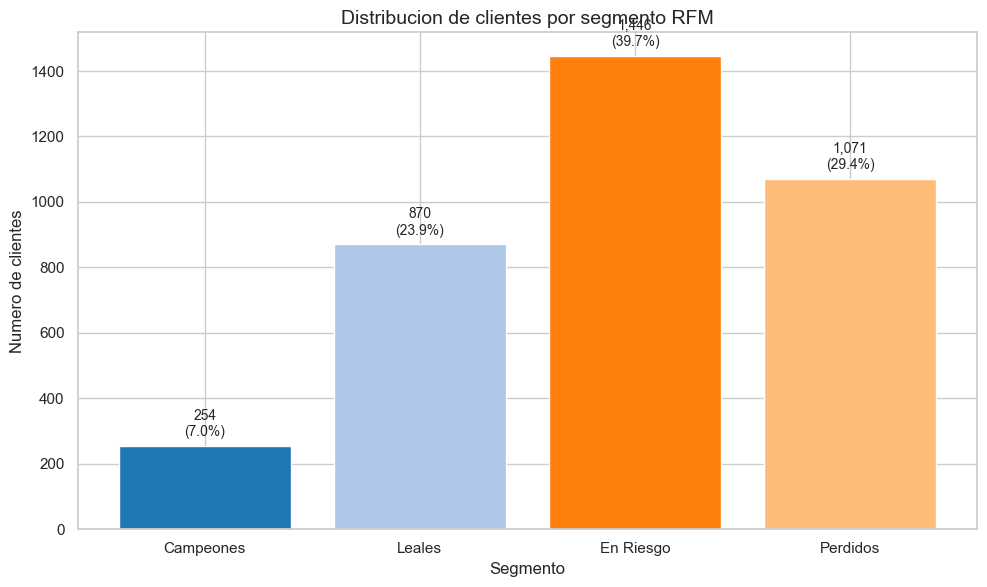

In [11]:
ORDEN_SEGMENTOS = ["Campeones", "Leales", "En Riesgo", "Perdidos"]

conteo_segmentos = (
    rfm_perfil["Segmento"].value_counts()
    .reindex(ORDEN_SEGMENTOS)
    .reset_index()
)
conteo_segmentos.columns = ["Segmento", "n_clientes"]
conteo_segmentos["pct"] = conteo_segmentos["n_clientes"] / conteo_segmentos["n_clientes"].sum() * 100

fig, ax = plt.subplots(figsize=(10, 6))
barras = ax.bar(
    conteo_segmentos["Segmento"], conteo_segmentos["n_clientes"],
    color=PALETA_FISIMART[:len(ORDEN_SEGMENTOS)],
)
for barra, pct in zip(barras, conteo_segmentos["pct"]):
    ax.annotate(
        f"{int(barra.get_height()):,}\n({pct:.1f}%)",
        xy=(barra.get_x() + barra.get_width() / 2, barra.get_height()),
        xytext=(0, 5), textcoords="offset points",
        ha="center", va="bottom", fontsize=10,
    )

ax.set_title("Distribucion de clientes por segmento RFM")
ax.set_xlabel("Segmento")
ax.set_ylabel("Numero de clientes")

plt.tight_layout()
plt.savefig('../reports/figures/07_distribucion_segmentos.png', dpi=300)
plt.show()


#### CELDA 12: HEATMAP DE PERFILES

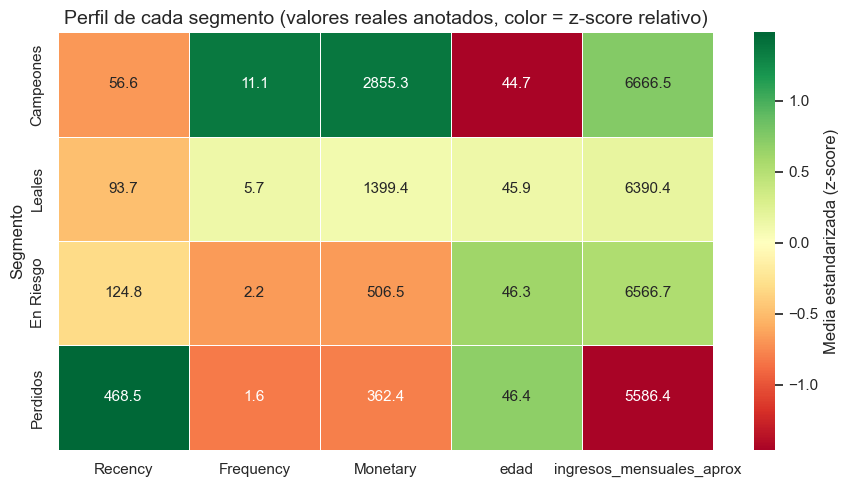

In [12]:
columnas_heatmap = ["Recency", "Frequency", "Monetary", "edad", "ingresos_mensuales_aprox"]

medias_por_segmento = (
    rfm_perfil.groupby("Segmento")[columnas_heatmap]
    .mean()
    .reindex(ORDEN_SEGMENTOS)
)

medias_estandarizadas = (medias_por_segmento - medias_por_segmento.mean()) / medias_por_segmento.std()

fig, ax = plt.subplots(figsize=(9, 5))
sns.heatmap(
    medias_estandarizadas,
    annot=medias_por_segmento.round(1),
    fmt="",
    cmap="RdYlGn",
    center=0,
    linewidths=0.5,
    cbar_kws={"label": "Media estandarizada (z-score)"},
    ax=ax,
)
ax.set_title("Perfil de cada segmento (valores reales anotados, color = z-score relativo)")
ax.set_ylabel("Segmento")
ax.set_xlabel("")

plt.tight_layout()
plt.savefig('../reports/figures/08_perfiles_heatmap.png', dpi=300)
plt.show()


#### CELDA 13: ESTRATEGIAS COMERCIALES POR SEGMENTO

| Segmento | Perfil (R/F/M) | Objetivo | Acciones concretas |
|---|---|---|---|
| **Campeones** (254, 7.0%) | Recency baja, Frequency y Monetary altos | Retener y convertir en embajadores | Programa VIP con acceso anticipado a lanzamientos y promociones exclusivas; upgrade automatico a "Platino" en el programa de fidelizacion; encuestas de satisfaccion y solicitud de referidos (referral bonus); atencion prioritaria/personalizada en canal Online. |
| **Leales** (870, 23.9%) | Recency y Monetary buenos, Frequency media-alta | Aumentar frecuencia y ticket promedio | Cross-sell basado en las reglas de asociacion ya minadas (notebook 05); bundles y combos por categoria; recordatorios de recompra por email/app segun su ciclo de compra habitual; incentivos por acumulacion de puntos para subir de nivel en `segmento_programa`. |
| **En Riesgo** (1,446, 39.7%) | Recency moderada, Frequency y Monetary bajos | Incrementar frecuencia antes de que se pierdan | Es el segmento mas grande y de bajo compromiso: campanas de activacion con descuento en la 2da compra del mes; notificaciones push de productos de conveniencia (categorias de alta rotacion); pruebas de canasta minima con envio gratis para subir ticket promedio; monitoreo mensual de Recency para detectar quienes escalan a "Perdidos". |
| **Perdidos** (1,071, 29.4%) | Recency muy alta, Frequency y Monetary muy bajos | Reactivar o descartar de campanas costosas | Campana de "te extranamos" con descuento agresivo de reactivacion (unico uso); encuesta de motivo de abandono; dado que el segmento esta sobrerrepresentado por clientes "Basico" de bajos ingresos, evaluar oferta de menor ticket de entrada (productos economicos/tamanos pequenos) antes de invertir en descuentos altos; excluir de campanas premium de alto costo por bajo retorno esperado. |

**Nota transversal:** el segmento "En Riesgo" es el mas grande (39.7% de la base activa) y
representa la mayor oportunidad de impacto: moverlos hacia "Leales" con incentivos de bajo
costo (recordatorios, bundles) tiene mejor retorno que intentar reactivar "Perdidos" uno por
uno.

#### CELDA 14: EXPORTACION PARA POWER BI

In [13]:
columnas_export = [
    "id_cliente", "Recency", "Frequency", "Monetary",
    "R_Score", "F_Score", "M_Score", "RFM_Score",
    "Cluster", "Segmento",
    "edad", "ingresos_mensuales_aprox", "segmento_programa", "distrito",
]

df_export = rfm_perfil[columnas_export].copy()
df_export["Monetary"] = df_export["Monetary"].round(2)

df_export.to_csv(ARCHIVO_SEGMENTACION_EXPORT, sep=";", index=False, encoding="utf-8")

print(f"✓ Segmentacion exportada: {len(df_export):,} clientes")
print(f"✓ Archivo generado      : {ARCHIVO_SEGMENTACION_EXPORT}")
print("\nVista previa del archivo para Power BI:")
display(df_export.head(10))


✓ Segmentacion exportada: 3,641 clientes
✓ Archivo generado      : ../data/processed/Segmentacion_Clientes.csv

Vista previa del archivo para Power BI:


,id_cliente,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score,Cluster,Segmento,edad,ingresos_mensuales_aprox,segmento_programa,distrito
0,CLI00002,354,5,744.70,2,4,3,243,2,Perdidos,61,9293.05,Regular,Miraflores
1,CLI00003,467,1,28.80,1,1,1,111,2,Perdidos,37,2565.61,Basico,Miraflores
2,CLI00004,11,14,2930.78,5,5,5,555,1,Campeones,28,11692.72,Platino,San Borja
3,CLI00007,16,4,926.50,5,4,4,544,0,Leales,37,11919.26,Premium,Comas
4,CLI00009,165,5,761.02,3,4,3,343,0,Leales,19,1885.42,Basico,San Miguel
5,CLI00010,412,1,42.64,1,1,1,111,2,Perdidos,65,2668.50,Basico,San Miguel
6,CLI00012,243,2,244.93,2,2,2,222,3,En Riesgo,36,6051.25,Premium,Los Olivos
7,CLI00013,10,8,1355.29,5,5,5,555,0,Leales,68,8264.38,Regular,Los Olivos
8,CLI00014,9,2,717.54,5,2,3,523,3,En Riesgo,57,6134.36,Regular,Miraflores
9,CLI00015,196,1,320.62,3,1,2,312,3,En Riesgo,55,3268.78,Premium,Comas
